In [1]:
import sys
import warnings
sys.path.append('..') 

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.metrics import accuracy_score, f1_score, log_loss, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc

warnings.filterwarnings('ignore')

SEED = 42
TARGET_NAMES = ['Dropout', 'Enrolled', 'Graduate']

df_clean = pd.read_csv("../data/processed/data_final.csv")
y = df_clean['Target']
X = df_clean.drop(columns=['Target'])

ALL_FEATURES = X.columns.tolist()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

CAT_COLS = ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
for col in CAT_COLS:
    X_train_raw[col] = X_train_raw[col].astype(str)
    X_test_raw[col] = X_test_raw[col].astype(str)

te = TargetEncoder(cols=CAT_COLS, smoothing=10)
X_tr = te.fit_transform(X_train_raw, y_train)
X_te = te.transform(X_test_raw)

sc = StandardScaler()
X_tr_sc = pd.DataFrame(sc.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
X_te_sc = pd.DataFrame(sc.transform(X_te),     columns=X_te.columns, index=X_te.index)

X_tr_full = X_tr_sc.values
X_te_full = X_te_sc.values
y_tr_np   = y_train.values

X_base, X_dsel, y_base, y_dsel = train_test_split(
    X_tr_full, y_tr_np, test_size=0.30, stratify=y_tr_np, random_state=SEED
)


dcs_data = joblib.load('../models/dcs_lca_model.pkl')
pool_specialist = dcs_data['pool_specialist']
best_k          = dcs_data['best_k']

harvest_data = joblib.load('../models/baseline_probability_harvesting.pkl')
harvest_proba  = harvest_data['harvest_proba']
y_pred_harvest = harvest_data['y_pred_harvest']

from src.dcs_lca import dcs_lca_predict



In [2]:
from sklearn.neighbors import NearestNeighbors

def dcs_lca_predict_proba(pool, X_dsel, y_dsel, X_test, k=7):
    X_dsel_arr = np.array(X_dsel)
    X_test_arr = np.array(X_test)
    y_dsel_arr = np.array(y_dsel)

    nn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
    nn.fit(X_dsel_arr)
    _, nbr_idx = nn.kneighbors(X_test_arr)

    final_probas = []
    for i, neighbors in enumerate(nbr_idx):
        y_nbr = y_dsel_arr[neighbors]
        X_nbr = X_dsel_arr[neighbors]
        x_i   = X_test_arr[i:i+1]
        
        best_lca = -1.0
        chosen_clf = None
        
        for clf in pool:
            pred_class = clf.predict(x_i)[0]
            mask = y_nbr == pred_class
            lca  = np.mean(clf.predict(X_nbr[mask]) == y_nbr[mask]) if mask.sum() > 0 else 0.0
            if lca > best_lca:
                best_lca = lca
                chosen_clf = clf
                
        proba_i = chosen_clf.predict_proba(x_i)[0]
        final_probas.append(proba_i)
        
    return np.array(final_probas)

y_pred_dcs  = dcs_lca_predict(pool_specialist, X_dsel, y_dsel, X_test=X_te_full, k=best_k)

y_proba_dcs = dcs_lca_predict_proba(pool_specialist, X_dsel, y_dsel, X_test=X_te_full, k=best_k)


In [7]:
from IPython.display import display

metrics_summary = {
    "Evaluations Metrics": ["Accuracy", "Log Loss", "ROC-AUC (Macro)", "F1-Score Macro", "F1 Dropout (Class 0)", "F1 Enrolled (Class 1)", "F1 Graduate (Class 2)"],
    "Baseline: Probability Harvesting": [
        accuracy_score(y_test, y_pred_harvest),
        log_loss(y_test, harvest_proba),
        roc_auc_score(y_test, harvest_proba, multi_class='ovr', average='macro'),
        f1_score(y_test, y_pred_harvest, average='macro'),
        f1_score(y_test, y_pred_harvest, average=None)[0],
        f1_score(y_test, y_pred_harvest, average=None)[1],
        f1_score(y_test, y_pred_harvest, average=None)[2]
    ],
    "Proposed: DCS-LCA": [
        accuracy_score(y_test, y_pred_dcs),
        log_loss(y_test, y_proba_dcs),
        roc_auc_score(y_test, y_proba_dcs, multi_class='ovr', average='macro'),
        f1_score(y_test, y_pred_dcs, average='macro'),
        f1_score(y_test, y_pred_dcs, average=None)[0],
        f1_score(y_test, y_pred_dcs, average=None)[1],
        f1_score(y_test, y_pred_dcs, average=None)[2]
    ]
}

df_metrics = pd.DataFrame(metrics_summary)

df_metrics["Improvement (Delta)"] = df_metrics["Proposed: DCS-LCA"] - df_metrics["Baseline: Probability Harvesting"]

df_metrics.loc[df_metrics["Evaluations Metrics"] == "Log Loss", "Improvement (Delta)"] = \
    df_metrics["Baseline: Probability Harvesting"] - df_metrics["Proposed: DCS-LCA"]

print("GLOBAL PERFORMANCE COMPARISON TABLE:")
display(df_metrics.style.format({
    "Baseline: Probability Harvesting": "{:.4f}",
    "Proposed: DCS-LCA": "{:.4f}",
    "Improvement(Delta)": "{:+.4f}"
}).set_properties(**{'text-align': 'left'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')]}
]))

GLOBAL PERFORMANCE COMPARISON TABLE:


,Evaluations Metrics,Baseline: Probability Harvesting,Proposed: DCS-LCA,Improvement (Delta)
0,Accuracy,0.8897,0.9162,0.026536
1,Log Loss,0.8979,0.2687,0.629201
2,ROC-AUC (Macro),0.9697,0.9785,0.008763
3,F1-Score Macro,0.8262,0.8638,0.037641
4,F1 Dropout (Class 0),0.8673,0.9130,0.045745
5,F1 Enrolled (Class 1),0.6710,0.7261,0.055147
6,F1 Graduate (Class 2),0.9404,0.9524,0.012030


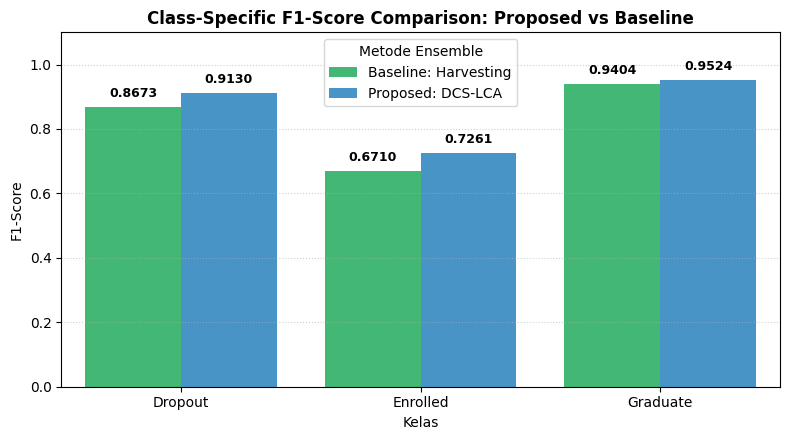

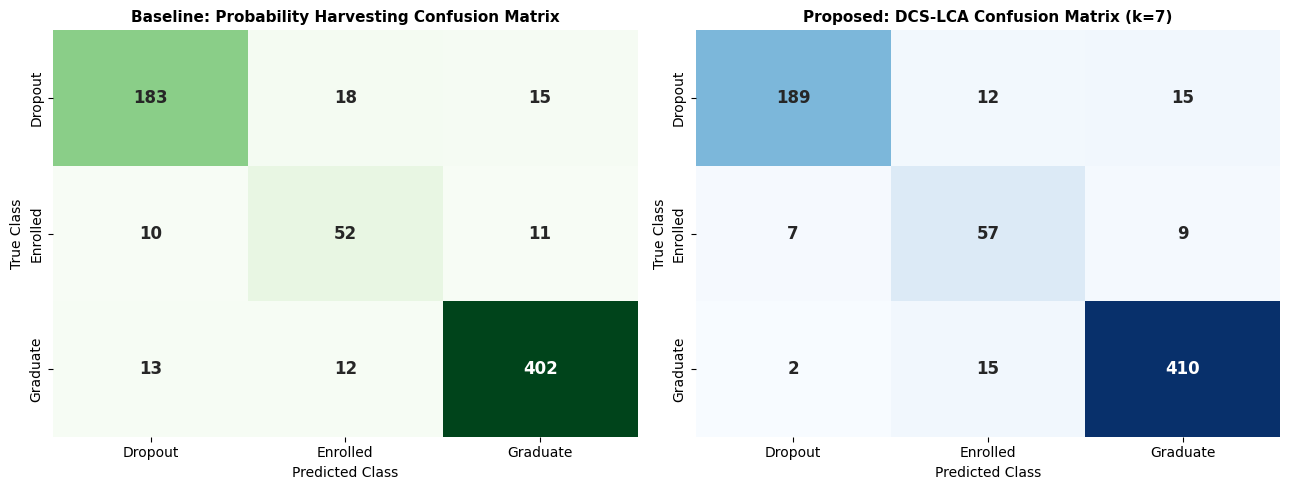

In [8]:

f1_harvest_c = f1_score(y_test, y_pred_harvest, average=None)
f1_dcs_c     = f1_score(y_test, y_pred_dcs, average=None)

df_f1_plot = pd.DataFrame({
    'Kelas': TARGET_NAMES * 2,
    'F1-Score': np.concatenate([f1_harvest_c, f1_dcs_c]),
    'Metode Ensemble': ['Baseline: Harvesting'] * 3 + ['Proposed: DCS-LCA'] * 3
})

plt.figure(figsize=(8, 4.5))
sns.barplot(x='Kelas', y='F1-Score', hue='Metode Ensemble', data=df_f1_plot, palette=['#2ecc71', '#3498db'])
plt.title('Class-Specific F1-Score Comparison: Proposed vs Baseline', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                    ha='center', va='center', fontsize=9, fontweight='bold', xytext=(0, 5), textcoords='offset points')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('../output/f1_score_class_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

cm_harvest = confusion_matrix(y_test, y_pred_harvest)
cm_dcs     = confusion_matrix(y_test, y_pred_dcs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm_harvest, annot=True, fmt='d', cmap='Greens', ax=axes[0], xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, cbar=False, annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title("Baseline: Probability Harvesting Confusion Matrix", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("True Class")

sns.heatmap(cm_dcs, annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, cbar=False, annot_kws={"size": 12, "weight": "bold"})
axes[1].set_title(f"Proposed: DCS-LCA Confusion Matrix (k={best_k})", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("True Class")

plt.tight_layout()
plt.savefig('../output/confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

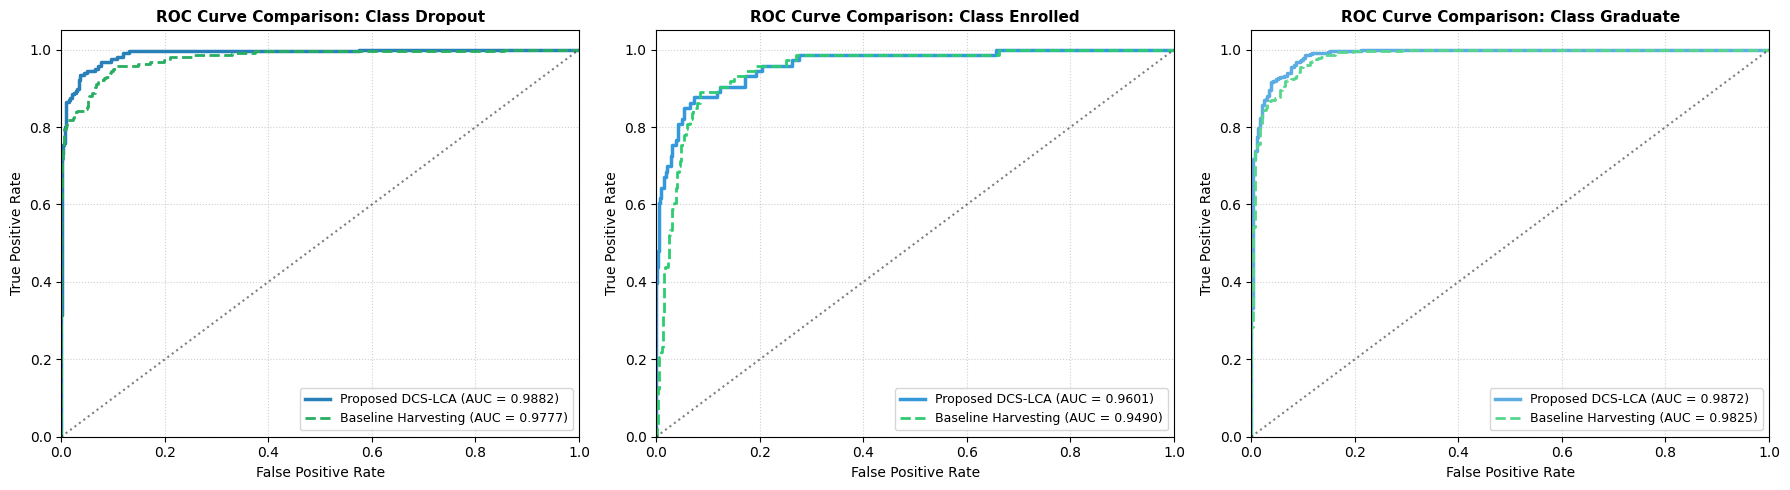

In [9]:

y_test_bin = pd.get_dummies(y_test).values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_dcs = ['#2980b9', '#3498db', '#5dade2']
colors_har = ['#27ae60', '#2ecc71', '#58d68d']

for i in range(3):

    fpr_dcs, tpr_dcs, _ = roc_curve(y_test_bin[:, i], y_proba_dcs[:, i])
    auc_dcs = auc(fpr_dcs, tpr_dcs)
    axes[i].plot(fpr_dcs, tpr_dcs, color=colors_dcs[i], linestyle='-', linewidth=2.5,
                 label=f'Proposed DCS-LCA (AUC = {auc_dcs:.4f})')
    

    fpr_har, tpr_har, _ = roc_curve(y_test_bin[:, i], harvest_proba[:, i])
    auc_har = auc(fpr_har, tpr_har)
    axes[i].plot(fpr_har, tpr_har, color=colors_har[i], linestyle='--', linewidth=2,
                 label=f'Baseline Harvesting (AUC = {auc_har:.4f})')
    
    axes[i].plot([0, 1], [0, 1], 'k:', alpha=0.5)
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate', fontsize=10)
    axes[i].set_ylabel('True Positive Rate', fontsize=10)
    axes[i].set_title(f'ROC Curve Comparison: Class {TARGET_NAMES[i]}', fontsize=11, fontweight='bold')
    axes[i].legend(loc="lower right", fontsize=9)
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('../output/roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
from rich.console import Console
from rich.table import Table

meta_idx = joblib.load('../models/specialist_feature_indices.pkl')

y_pred_xgb = joblib.load('../models/specialist_enrolled_xgb.pkl').predict(X_te_full[:, meta_idx['xgb_idx']])
y_pred_svm = joblib.load('../models/specialist_graduate_svm.pkl').predict(X_te_full[:, meta_idx['svm_idx']])
y_pred_nb  = joblib.load('../models/specialist_dropout_nb.pkl').predict(X_te_full[:, meta_idx['nb_idx']])

df_div = pd.DataFrame({
    'XGB_Enrolled': y_pred_xgb, 
    'SVM_Graduate': y_pred_svm, 
    'NB_Dropout': y_pred_nb,    
    'Real_Target': y_test.values,
    'Harvest_Decision': y_pred_harvest,
    'DCS_LCA_Decision': y_pred_dcs
})

df_div['Is_Diverse'] = ~((df_div['XGB_Enrolled'] == df_div['SVM_Graduate']) & (df_div['SVM_Graduate'] == df_div['NB_Dropout']))

n_total = len(df_div)
n_disagreement = df_div['Is_Diverse'].sum()

dcs_saved = ((df_div['Is_Diverse']) & (df_div['DCS_LCA_Decision'] == df_div['Real_Target'])).sum()
harvest_saved = ((df_div['Is_Diverse']) & (df_div['Harvest_Decision'] == df_div['Real_Target'])).sum()


console = Console()
table = Table(title="ENSEMBLE DECISION DIVERSITY", title_style="bold cyan")

table.add_column("Evaluation Metric / Analysis Case", justify="left", style="white")
table.add_column("Count (Samples)", justify="right", style="magenta")
table.add_column("Percentage (%)", justify="right", style="yellow")

table.add_row("Total Sample Test Set", f"{n_total}", "100.0%")
table.add_row("Total Samples Triggering Prediction Conflicts", f"{n_disagreement}", f"{n_disagreement/n_total*100:.1f}%")
table.add_section()
table.add_row("Successfully Resolved by DCS-LCA", f"{dcs_saved}", f"{dcs_saved/n_disagreement*100:.1f}%", style="bold green")
table.add_row("Successfully Resolved by Harvesting (Baseline)", f"{harvest_saved}", f"{harvest_saved/n_disagreement*100:.1f}%", style="bold red")

console.print(table)

                             ENSEMBLE DECISION DIVERSITY                             
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Evaluation Metric / Analysis Case              ┃ Count (Samples) ┃ Percentage (%) ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ Total Sample Test Set                          │             716 │         100.0% │
│ Total Samples Triggering Prediction Conflicts  │             108 │          15.1% │
├────────────────────────────────────────────────┼─────────────────┼────────────────┤
│ Successfully Resolved by DCS-LCA               │              70 │          64.8% │
│ Successfully Resolved by Harvesting (Baseline) │              51 │          47.2% │
└────────────────────────────────────────────────┴─────────────────┴────────────────┘